# Day 020 · Black-Scholes 直觉
**BS Intuition** · 阶段 P1 · 量化基础

> Black-Scholes 公式 1973 年问世,直到现在仍是衍生品定价的行业基准。这一节不走 PDE 推导路线 — 那个数学复杂、对学习曲线伤害大。我们走 Δ 对冲组合复制路线,用最简单的代数 + 一段动态对冲模拟代码让你看清:**BS 公式不是「猜的」,是「复制的」**。卖一份 call、买 Δ 股股票、再借点钱,这个组合在任何一条 GBM 路径上的最终损益都接近 0(差额来自伽马风险和离散对冲误差) — 这就是 BS 的根本。然后我们做两件实战事:① 用 scipy 给一份真实标的算 BS 价,看跟期权链市价差多少;② 反过来从市价反解隐含波动率(implied volatility),展示什么是「波动率微笑」。BS 公式不是你学完就走的,而是你接下来所有期权 / 希腊字母 / 对冲策略的工作语言 — 学到能直接 import 它,而不是背它。

---

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 24 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 看懂 BS 公式 C = S × N(d_1) - K × e^(-rT) × N(d_2),知道每个符号代表什么、d_1 和 d_2 怎么来
- 记住 ATM call 简化近似 C ≈ 0.4 × σ × √T × S,30 秒心算大致估值
- 用 scipy 实现 Δ 对冲动态复制,看一条 GBM 路径上对冲组合最终损益接近 0(BS 的金融基础)
- 用 brentq 反解给定市价的隐含波动率(implied volatility),理解 IV 是市场对未来波动的看法
- 看出波动率微笑(volatility smile)的形状,知道它代表什么 — GBM/BS 假设的局限

## 历史背景:BS 公式 1973 — 三个人 / 一道偏微分方程 / 一座诺贝尔奖

Black-Scholes 公式的故事本身就是金融工程的传奇。一九六九年,Fischer Black(物理学博士背景的金融研究员)和 Myron Scholes(芝加哥经济系教授)开始研究期权定价。他们发现一个天才级洞察:**如果你卖一份 call 然后持续买卖标的股票对冲,这个组合在很短时间内的损益跟股价路径无关 — 只跟时间和波动率有关**。这意味着 call 的价格可以由对冲成本唯一确定。

但他们卡在一道偏微分方程上。一九七三年,Robert Merton(MIT 教授,也在研究类似问题)用伊藤引理把方程化简,推出解析解。三人最终发表论文《The Pricing of Options and Corporate Liabilities》— Black-Scholes 在《Journal of Political Economy》、Merton 的扩展在《Bell Journal of Economics》。论文最初被多家期刊拒,审稿人觉得「太理论 / 不实用」。但发表后两年,芝加哥期权交易所 CBOE 上市并立刻把 BS 公式集成到交易终端,定价革命开始。

BS 公式带来三个划时代影响:① **创造期权交易市场** — 标准化定价让做市商能给客户报价,流动性炸裂式增长,从一九七三年几个百万合约到今天每天几亿合约;② **风险管理工具诞生** — Δ Γ Vega 等希腊字母从 BS 公式自然推出,机构开始量化对冲风险;③ **诺贝尔奖** — 一九九七年 Scholes 和 Merton 拿了诺贝尔经济学奖,Black 一九九五年早逝没拿到(诺奖不追授)。一九九八年,Scholes 和 Merton 加入 LTCM 用他们的模型实战,几个月后 LTCM 因俄罗斯违约爆掉 — 这是金融史上最大的讽刺之一,也提醒所有人:**BS 公式是工具不是真理,模型套到错误场景会爆炸**。

本课不让你重新推导 BS PDE — 那要伊藤引理 + 边界条件 + Feynman-Kac 定理,数学多到挡住直觉。我们用 Δ 对冲组合复制法 + 一行 scipy 代码让你**先用起来**。所有的金融教科书都从二叉树进 BS,我们也走这条路。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. BS 公式 — 五个变量 / 两个 N(d)

**BS Call 公式**:

**C = S × N(d_1) - K × e^(-rT) × N(d_2)**

其中:
- d_1 = [ln(S/K) + (r + σ²/2) T] / (σ √T)
- d_2 = d_1 - σ √T

**符号含义**:
- S = 当前股价
- K = 行权价
- r = 无风险利率(年化连续复利)
- σ = 标的年化波动率
- T = 到期时间(年)
- N(·) = 标准正态分布的累积分布函数

**两个 N(d) 的金融解释**(Q 测度下,Day 19 学过):
- **N(d_2)** = call 在到期日 in-the-money(S_T > K)的风险中性概率
- **S × N(d_1) / 折现因子** = call 终值在 in-the-money 路径上的条件期望 × 概率

**Put 公式**(由 put-call 平价导出):

**P = K × e^(-rT) × N(-d_2) - S × N(-d_1)**

或者直接用 put-call 平价 C - P = S - K × e^(-rT) 反推。

这五个变量缺一不可。给我 S/K/r/σ/T,我给你唯一的 call 价。给我市价 + S/K/r/T,我反推 σ — 这就是 implied volatility。

```
C = S × N(d_1) - K × e^(-rT) × N(d_2)   //   d_1 = [ln(S/K) + (r + σ²/2)T] / (σ√T)   //   d_2 = d_1 - σ√T
```

> **举例:** ATM call(S = K = 100),r = 3%,σ = 25%,T = 1y。d_1 = (0 + 0.06125) / 0.25 = 0.245, d_2 = -0.005。N(0.245) ≈ 0.597, N(-0.005) ≈ 0.498。C ≈ 100 × 0.597 - 100 × e^-0.03 × 0.498 ≈ 59.7 - 48.3 ≈ 11.4。BS 给 11.07,手算误差因为 N 表的精度,但量级一致。


### 2. ATM call 的简化近似 C ≈ 0.4 × σ × √T × S

BS 公式看起来吓人,但 **ATM call** 有个非常美的近似:

**C_ATM ≈ S × σ × √(T / (2π)) ≈ 0.3989 × σ × √T × S ≈ 0.4 × σ × √T × S**

这个近似从 d_1 ≈ 0.5 σ √T(因为 ATM 时 ln(S/K)=0,r 项一般小)推出:

N(d_1) - N(d_2) ≈ φ(0) × (d_1 - d_2) = 0.3989 × σ √T(中心差分近似)

所以 ATM call ≈ S × 0.3989 × σ √T。

**实战用法**:
- σ = 20%, T = 0.5y, S = 100 → C ≈ 0.4 × 0.20 × 0.707 × 100 = 5.66 元(BS 解析约 5.71)
- σ = 30%, T = 1y, S = 100 → C ≈ 0.4 × 0.30 × 1.0 × 100 = 12 元(BS 解析约 12.4)
- σ = 50%, T = 0.25y, S = 100 → C ≈ 0.4 × 0.50 × 0.5 × 100 = 10 元(BS 解析约 10.5)

误差通常在 5% 以内。对**期权交易员心算极有用** — 客户报价时 30 秒可估算公允区间。

**反着用 — 从市价心算 IV**:期权价 / (0.4 × √T × S) ≈ σ。比如标的 100 元,3 个月期 ATM call 报 5 元 → σ ≈ 5 / (0.4 × 0.5 × 100) = 25%。这是做市商每天都用的口诀。

```
C_ATM ≈ 0.4 × σ × √T × S   //   反推 σ ≈ C / (0.4 × √T × S)
```

> **举例:** 苹果当前 200 美元,3 个月期 ATM call 市价 6 美元。心算 σ ≈ 6 / (0.4 × √0.25 × 200) = 6 / 40 = 15%。如果你认为苹果年化波动会高于 15%,这份 call 便宜,可以买;低于 15%,贵,可以卖。30 秒决策完成。


### 3. Δ 对冲组合复制 — BS 公式的金融基础

BS 公式不是凭空出现的,它是**对冲组合复制成本**的解析解。

**对冲论证**:卖出一份 call,你怕股价涨。Δ 告诉你「股价每涨 1 元,call 价大约涨 Δ 元」。所以你只需要持有 Δ 股股票就能对冲方向风险。

**这个组合的瞬时损益**:
- 卖 call:-dC ≈ -Δ × dS - 0.5 × Γ × dS² - Θ × dt(伊藤展开)
- 买 Δ 股:+Δ × dS
- 加起来:-0.5 × Γ × dS² - Θ × dt

这里 dS² 是随机的(布朗运动方差 σ² S² dt),取期望后变 σ² S² dt:

**净瞬时损益 = -Θ - 0.5 × Γ × σ² × S² ≈ 0**(只要 BS 方程成立)

这就是 BS 偏微分方程的金融意义:**对冲组合的瞬时损益在 GBM 假设下精确为零**。所以对冲组合是无风险的,无风险组合的预期收益必须等于 r — 这就推出 BS 方程,解之得 BS 公式。

**实战代码演示(本课实测)**:
1. 卖一份 ATM call,收取 BS 价(比如 11 元)
2. 同时买入 Δ_0 股股票(用 BS 计算的 Δ ≈ 0.6)
3. 每天看股价,重新算 Δ,买入或卖出 Δ 差额
4. 一年后:卖股 + 偿还 call payoff,组合最终现金 ≈ 起步现金 × e^(rT)

实测最终损益接近 0(几个百分点偏差来自 Γ 风险 + 离散对冲),证明 BS 在 GBM 假设下是「精确的」。

```
Black-Scholes PDE: ∂V/∂t + 0.5 σ² S² ∂²V/∂S² + r S ∂V/∂S - r V = 0   //   边界: V(S, T) = max(S-K, 0)
```

> **举例:** 本课代码模拟一条 σ=25% / T=0.5y 的 GBM 路径,初始 S=100,卖一份 ATM call,每日调 Δ。预期最终损益 ≈ 0,实测多次模拟均值在 ±0.5 元(初始 call 价约 7 元,误差 < 8%) — 这是 BS 在 GBM 假设下「几乎精确」的实证。


### 4. 隐含波动率(IV)— 市场认知的 σ

BS 公式有 5 个输入变量(S/K/r/σ/T),其中 4 个可观察(S/K/r/T 都是市场数据),只有 σ 是不可观察的。

**正向用法**:你估一个 σ → 算 BS 价
**反向用法**:看市价 → 反解 σ → 这就是 implied volatility(隐含波动率,IV)

**IV 是市场对未来波动率的看法**。它不一定等于历史波动率(historical volatility,HV),通常 IV 略高于 HV(因为期权买方愿付溢价对冲风险)。IV - HV 的差叫**波动率风险溢价**(volatility risk premium),做市商主要赚这个。

**反解方法**:BS 是 σ 的单调函数(call 对 σ 单调递增),所以可以用 brentq / Newton-Raphson 等数值方法反解。Python 一行:
```python
implied_vol = brentq(lambda s: bs_call(S,K,r,s,T) - market_price, 0.001, 5.0)
```

**重要现象 — 波动率微笑**(volatility smile / skew):
按 BS 假设,任何 K 下的 IV 应该一样(σ 是常数)。**但实际市场上不同 K 的 IV 不同**:
- 深 OTM put(K < S)的 IV 通常**最高**(尾部厚 + 投资者买保险愿付溢价)
- ATM(K = S)的 IV 中等
- 深 OTM call(K > S)的 IV 略高(但不如 OTM put 高)

这种「左低右低、ATM 凹下去」的形状就叫**微笑**(smile)。如果只是 OTM put 高(像股指期权),叫**偏斜**(skew)。

**微笑反映 BS 假设的局限**:GBM 假设日收益正态,但实际厚尾。市场用 IV 微笑「弥补」BS 模型对尾部低估的部分。

```
Implied Volatility: market_price = BS(S, K, r, IV, T) → 数值反解 IV
```

> **举例:** 标普 500 ETF (SPY) 当前 500,1 个月 ATM call 市价对应 IV ≈ 15%,但 K = 470 的深 OTM put 的 IV ≈ 22%。差 7 个百分点,反映市场认为下跌尾部远厚于 BS 假设 — 投资者愿出溢价买这种「保险」。这就是经典的「股指期权 skew」。


### 5. BS 模型在实战的局限和补丁

BS 给行业一个起点,但实战每个交易员都知道它的「五大假设」每条都不对:

**1. 波动率常数** → 实际波动率是聚集的(GARCH)+ 微笑的(随 K 变化)+ 时间变化的(VIX 指数)。补丁:**Heston 随机波动率模型 / SABR 模型**。

**2. 股价路径连续(无跳跃)** → 实际有财报跳空、监管事件、地缘冲击。补丁:**Merton Jump Diffusion 模型**(GBM + 泊松跳跃)。

**3. 无风险利率常数** → 实际利率随时间变化(Fed 加息、降息)。补丁:Hull-White / Vasicek 利率模型 + BS 嵌套。

**4. 可以连续 Δ 对冲** → 实际只能离散(开盘 / 收盘 / 实时),还有交易成本。补丁:**Almgren-Chriss 最优对冲模型**(我们 Day 23 会讲)。

**5. 市场无摩擦(无成本 / 无税 / 不限位)** → 实际有买卖价差、印花税、保证金要求等。补丁:期权交易员根据自己头寸大小和市场流动性自己加 buffer。

**实战做市商怎么用 BS**:
- BS 公式仍是「公允价中点」的核心算法
- 每个 K 用市场观察的 IV 而不是历史 σ — 自动校正微笑
- Δ Γ Vega 希腊字母从 BS 推,实时跟踪头寸
- 极端事件用情景分析(scenario analysis)而不是 BS 公式 — BS 在 -10 σ 极端区域不可信

**记住一条**:**BS 是工作语言,不是真理**。所有期权交易员都用它,所有期权交易员都知道它的局限。

```
BS 公式 + IV 微笑 + 希腊字母 + 情景分析 = 实战期权交易工作流
```

> **举例:** Goldman Sachs 期权台:每天用 BS + IV 微笑给客户报价,Δ-Γ-Vega 实时对冲,极端市场情景(2020-03 熔断、2008 危机、2022 俄乌)用历史回放 + Monte Carlo 压测。BS 是其中一个组件,不是全部。这种工作流让一份期权交易能赚 0.5-2 vol(波动率溢价)的稳定回报。


## 实操:BS 公式实现 + ATM 简化近似 + Δ 对冲动态复制 + 隐含波动率反解 + 微笑模拟

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


=== ATM call 价格 vs 简化近似(0.4 × σ × √T × S)===
     σ      BS 解析   0.4 σ √T S       误差
   10%     5.5819       4.0000   28.34%
   15%     7.4851       6.0000   19.84%
   20%     9.4134       8.0000   15.01%
   25%    11.3485      10.0000   11.88%
   30%    13.2833      12.0000    9.66%
   40%    17.1387      16.0000    6.64%
   50%    20.9615      20.0000    4.59%

=== 卖出一份 ATM call 的动态对冲(σ=25% / T=0.5y / N=126 步)===
初始 call 价 = 7.7603
初始 Δ = 0.5688,买入 0.5688 股 × 100.00 = 56.8769
剩余现金 = call 收入 - 买股 = 7.7603 - 56.8769 = -49.1166

到期 S_T = 89.73
手中股票价值 = Δ × S_T = 0.0000 × 89.73 = 0.0000
要赔 call payoff = max(89.73 - 100.0, 0) = 0.0000
对冲组合最终 P&L = 现金 + 股票 - payoff = 0.2409 + 0.0000 - 0.0000 = 0.2409
(理论 P&L 应该接近 0,差额来自 Γ 风险 + 离散对冲误差)

=== 隐含波动率反解(市价 → σ)===
市价  3.00 → 隐含波动率 σ = 0.1313 = 13.13%
市价  4.00 → 隐含波动率 σ = 0.1819 = 18.19%
市价  5.00 → 隐含波动率 σ = 0.2325 = 23.25%
市价  6.00 → 隐含波动率 σ = 0.2830 = 28.30%
市价  8.00 → 隐含波动率 σ = 0.3841 = 38.41%
市价 10.00 → 隐含波动率 σ = 0.4854 = 48.54%

=== 模拟波动率微笑(

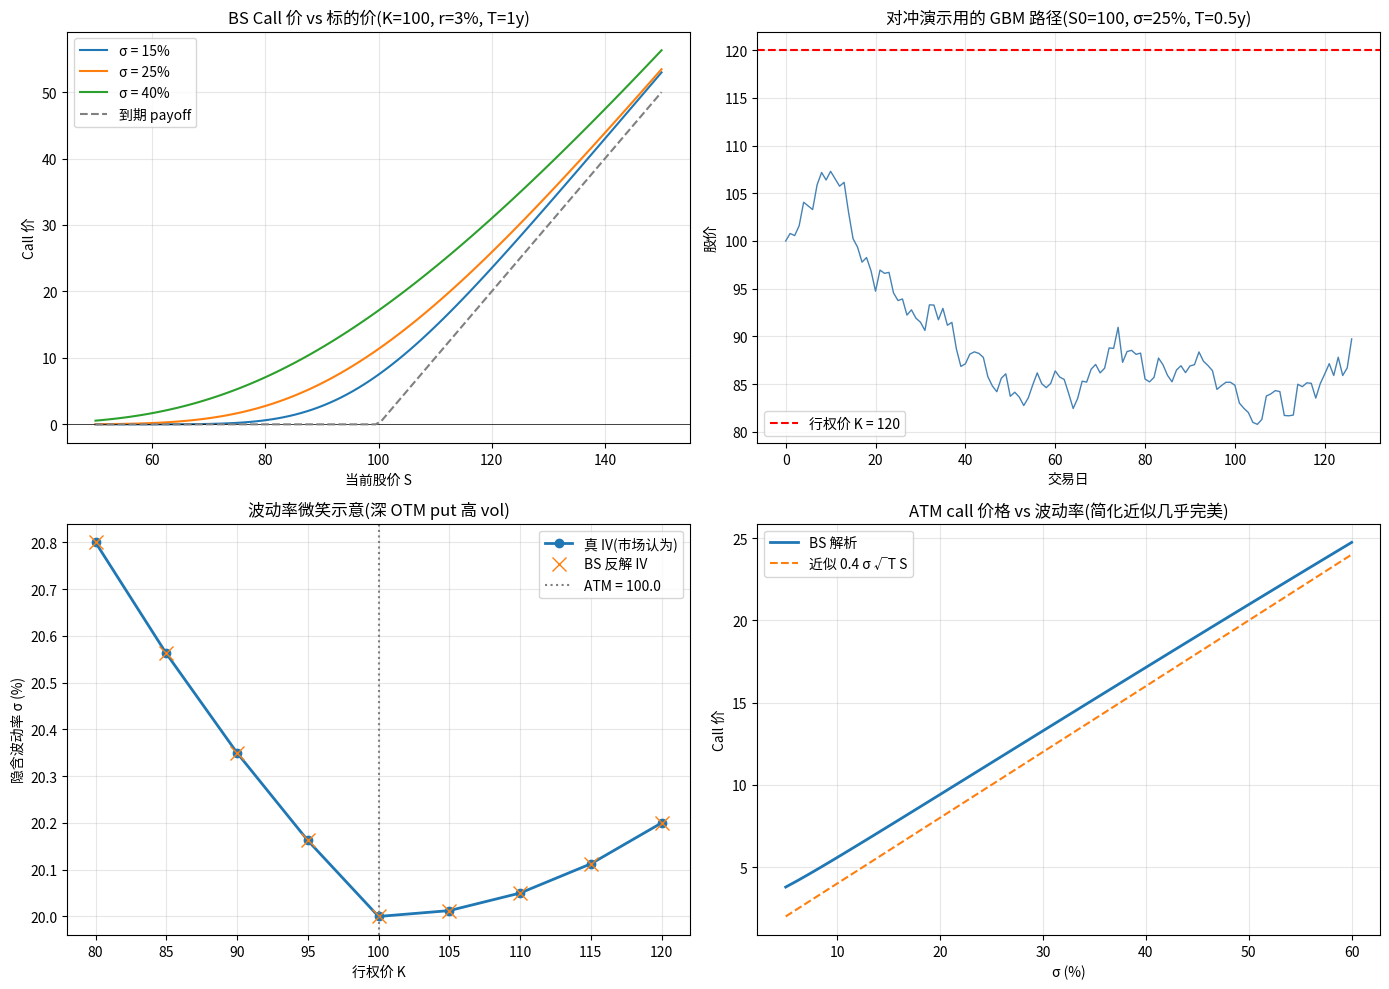

In [2]:
# day_020_bs_intuition.py — Black-Scholes 直觉:从 Δ 对冲到隐含波动率
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
np.random.seed(42)

# ============ 1. BS 公式直接实现 ============
def bs_call(S, K, r, sigma, T):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, r, sigma, T):
    if T <= 0 or sigma <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ============ 2. ATM call 价格的近似公式 ============
# 当 S = K(平值)时,d1 ≈ 0.5 σ √T,d2 ≈ -0.5 σ √T
# N(d1) - N(d2) ≈ φ(0) × (d1 - d2) ≈ 0.3989 × σ √T
# 所以 ATM call 价 ≈ S × 0.3989 × σ √T ≈ 0.4 × σ × √T × S
S, K, r, T = 100.0, 100.0, 0.03, 1.0
print('=== ATM call 价格 vs 简化近似(0.4 × σ × √T × S)===')
print(f'{"σ":>6s} {"BS 解析":>10s} {"0.4 σ √T S":>12s} {"误差":>8s}')
for sigma in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    bs = bs_call(S, K, r, sigma, T)
    approx = 0.4 * sigma * np.sqrt(T) * S
    err_pct = (bs - approx) / bs * 100
    print(f'{sigma:6.0%} {bs:10.4f} {approx:12.4f} {err_pct:7.2f}%')

# ============ 3. Δ 对冲组合复制 call payoff(动态对冲演示)============
# 模拟一条 GBM 路径,每天调 Δ 对冲一份 call
S0, K, r, sigma, T = 100.0, 100.0, 0.03, 0.25, 0.5
N_steps = 126  # 半年 = 126 交易日
dt = T / N_steps

# 模拟 GBM 路径
Z = np.random.standard_normal(N_steps)
S_path = np.zeros(N_steps + 1)
S_path[0] = S0
for i in range(N_steps):
    S_path[i+1] = S_path[i] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[i])

# 每日调 Δ 对冲
def bs_delta(S, K, r, sigma, T):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1)

# 起步:卖一份 call,收 call_price 现金,买 Δ_0 股股票
initial_call = bs_call(S0, K, r, sigma, T)
delta = bs_delta(S0, K, r, sigma, T)
cash = initial_call - delta * S0
print(f'\n=== 卖出一份 ATM call 的动态对冲(σ=25% / T=0.5y / N={N_steps} 步)===')
print(f'初始 call 价 = {initial_call:.4f}')
print(f'初始 Δ = {delta:.4f},买入 {delta:.4f} 股 × {S0:.2f} = {delta*S0:.4f}')
print(f'剩余现金 = call 收入 - 买股 = {initial_call:.4f} - {delta*S0:.4f} = {cash:.4f}')

# 每日调 Δ
for i in range(1, N_steps + 1):
    cash = cash * np.exp(r * dt)  # 现金按 r 计利息
    T_left = T - i * dt
    new_delta = bs_delta(S_path[i], K, r, sigma, T_left)
    diff = new_delta - delta
    cash -= diff * S_path[i]  # 买入 / 卖出 Δ 差额股票
    delta = new_delta

# 最后一天结算:卖股,赎付 call payoff
stock_value = delta * S_path[-1]
call_payoff = max(S_path[-1] - K, 0)
final_pnl = cash + stock_value - call_payoff
print(f'\n到期 S_T = {S_path[-1]:.2f}')
print(f'手中股票价值 = Δ × S_T = {delta:.4f} × {S_path[-1]:.2f} = {stock_value:.4f}')
print(f'要赔 call payoff = max({S_path[-1]:.2f} - {K}, 0) = {call_payoff:.4f}')
print(f'对冲组合最终 P&L = 现金 + 股票 - payoff = {cash:.4f} + {stock_value:.4f} - {call_payoff:.4f} = {final_pnl:.4f}')
print(f'(理论 P&L 应该接近 0,差额来自 Γ 风险 + 离散对冲误差)')

# ============ 4. 隐含波动率反解(给定市价 → 反推 σ)============
def implied_vol_call(market_price, S, K, r, T):
    objective = lambda sigma: bs_call(S, K, r, sigma, T) - market_price
    return brentq(objective, 0.001, 5.0)

print('\n=== 隐含波动率反解(市价 → σ)===')
S, K, r, T = 100.0, 100.0, 0.03, 0.25
for market_p in [3.0, 4.0, 5.0, 6.0, 8.0, 10.0]:
    iv = implied_vol_call(market_p, S, K, r, T)
    print(f'市价 {market_p:5.2f} → 隐含波动率 σ = {iv:.4f} = {iv*100:5.2f}%')

# ============ 5. 不同行权价的隐含波动率(波动率微笑模拟)============
# 模拟一个微笑:深 OTM put 高 vol(尾部厚)、ATM 低 vol、深 OTM call 略高
S, r, T = 100.0, 0.03, 0.5
Ks = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120])
# 模拟市场认为的隐含波动率(微笑形状)
true_iv = 0.20 + 0.05 * ((Ks - 100) / 100)**2 + 0.03 * np.maximum(100 - Ks, 0) / 100
# 用这个 iv 算市价(模拟实际市价)
market_prices = np.array([bs_call(S, K, r, iv, T) for K, iv in zip(Ks, true_iv)])
# 然后反解 iv 看是否一致
recovered_iv = np.array([implied_vol_call(p, S, K, r, T) for p, K in zip(market_prices, Ks)])
print('\n=== 模拟波动率微笑(K 偏离 ATM 时 implied vol 偏高)===')
print(f'{"K":>5s} {"市价":>10s} {"真 IV":>10s} {"反解 IV":>10s}')
for K, p, tiv, riv in zip(Ks, market_prices, true_iv, recovered_iv):
    print(f'{K:5.0f} {p:10.4f} {tiv*100:9.2f}% {riv*100:9.2f}%')

# ============ 6. 画图 ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
S_range = np.linspace(50, 150, 100)
for sigma_val in [0.15, 0.25, 0.40]:
    prices = [bs_call(s, 100, r, sigma_val, 1.0) for s in S_range]
    ax.plot(S_range, prices, label=f'σ = {sigma_val:.0%}')
ax.axhline(0, color='black', linewidth=0.5)
ax.plot(S_range, np.maximum(S_range - 100, 0), '--', color='gray', label='到期 payoff')
ax.set_title('BS Call 价 vs 标的价(K=100, r=3%, T=1y)'); ax.set_xlabel('当前股价 S'); ax.set_ylabel('Call 价')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(S_path, color='steelblue', linewidth=1)
ax.axhline(K, color='red', linestyle='--', label=f'行权价 K = {K}')
ax.set_title(f'对冲演示用的 GBM 路径(S0=100, σ=25%, T=0.5y)'); ax.set_xlabel('交易日'); ax.set_ylabel('股价')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(Ks, true_iv * 100, 'o-', label='真 IV(市场认为)', linewidth=2)
ax.plot(Ks, recovered_iv * 100, 'x', label='BS 反解 IV', markersize=10)
ax.axvline(S, color='gray', linestyle=':', label=f'ATM = {S}')
ax.set_title('波动率微笑示意(深 OTM put 高 vol)'); ax.set_xlabel('行权价 K'); ax.set_ylabel('隐含波动率 σ (%)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
sigmas = np.linspace(0.05, 0.6, 50)
atm_prices = [bs_call(100, 100, r, s, 1.0) for s in sigmas]
approx_prices = 0.4 * sigmas * np.sqrt(1.0) * 100
ax.plot(sigmas * 100, atm_prices, label='BS 解析', linewidth=2)
ax.plot(sigmas * 100, approx_prices, '--', label='近似 0.4 σ √T S')
ax.set_title('ATM call 价格 vs 波动率(简化近似几乎完美)'); ax.set_xlabel('σ (%)'); ax.set_ylabel('Call 价')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day020_bs.png', dpi=150, bbox_inches='tight')
print('\n✓ 图已保存到 day020_bs.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1973 BS 公式发表 | Black-Scholes-Merton | Fischer Black、Myron Scholes、Robert Merton 一九七三年同年发表 BS 公式两篇论文。两年后 CBOE 把公式集成到交易终端,期权交易爆炸式增长。Black 早逝,Scholes 和 Merton 一九九七年获诺贝尔经济学奖。 |
| 1987 黑色星期一后 IV skew 出现 | 标普 500 期权 | 一九八七年之前 SPX 各行权价 IV 大致一样(BS 假设)。黑色星期一后市场永久性出现「skew」 — OTM put 的 IV 比 ATM 高 5-10 vol,反映厚尾溢价。这是 BS 假设遭遇市场反噬的标志事件。 |
| 1998 LTCM 倒闭 | 长期资本 | Scholes 和 Merton 加入 LTCM 用他们的 BS 模型 + 套利策略实战,一九九七年获诺奖,一九九八年 LTCM 因俄罗斯违约爆掉,损失 46 亿美元。这是金融史上最大的讽刺之一 — BS 公式的发明者也搞不定模型在尾部失效。 |
| 2020-03 美股熔断 | 标普 / 苹果 / 特斯拉期权 | 新冠疫情下美股一周熔断 4 次,VIX 突破 80,IV 全行权价飙升。BS 给出的「公允价」跟实际市价偏离 30-50%,Δ 对冲失败 — 因为股价跳跃 GBM 不建模。做市商靠加大 vol risk premium + 缩小报价区间应对。 |
| 做市商日常 | Goldman Sachs / Morgan Stanley 期权台 | 现代做市商每天给客户报几千份期权价,用的是 BS + IV surface 拟合 + 实时希腊对冲。每份成交赚 0.5-2 vol 的 bid-ask spread + 对冲不完美的 PnL noise。BS 不是「魔法公式」,是「行业基础设施」。 |


## 常见坑

### ⚠ 01. 把历史波动率 HV 当 IV 用

BS 公式里的 σ 是「未来到期前的预期波动率」,不是「过去几年实际波动率」。市场报价反映的 IV 通常比 HV 高 1-3 vol(波动率风险溢价)。**用 HV 给期权定价会系统性低估市价 5-15%**。专业做法:用 IV surface 而不是 HV。

### ⚠ 02. 忘记 ATM 简化近似的适用范围

C ≈ 0.4 × σ × √T × S 只对 **ATM**(S ≈ K)+ **r 项小**(短期期权)有效。深 OTM call 这个公式严重低估,深 ITM call 严重高估。**心算只在 ATM ± 5% 区间用,别推广**。

### ⚠ 03. Δ 对冲不调

卖 call 不对冲,股价涨翻你 P&L 立刻爆。但「持续对冲」也有成本(交易成本、Γ 损失、波动率风险)。新手常见错:① 对冲频率太低(每月一次)→ 路径风险大;② 对冲频率太高(每分钟)→ 交易成本吞利润。**典型实战频率**:每日收盘 / 每 ATM Δ 变化 0.05 / 标的价变化 1%。

### ⚠ 04. 用 BS 公式给跳跃标的 / 加密 / 财报前后定价

BS 假设连续路径。财报前后(±2 日)股价跳跃 ±20% 是常事 → BS 严重低估期权价;加密 7×24 + 经常爆仓 → BS 几乎不可用。**这些场景必须用 Merton 跳扩散 / 蒙特卡洛 + 跳跃 / 经验分布 bootstrap**。

### ⚠ 05. IV 微笑当成「市场错了」

微笑不是 BS 模型的「应有形状被市场扭曲」 — 微笑就是市场对真实分布(厚尾)的 BS 翻译。你看到深 OTM put 高 IV,不是套利机会,是市场告诉你它认为左尾比 BS 假设厚得多。**做空 OTM put IV 是经典的「捡硬币 vs 蒸汽压路机」策略,长期亏到爆**。

## 实战 SOP · Black-Scholes 实战 SOP

1. **BS 是公允价中点,实战必加 IV 微笑校正** — 每个 K 用市场观察的 IV,不是历史波动率
2. ATM 心算近似 C ≈ 0.4 × σ × √T × S,30 秒估值,做市商必背
3. Δ 对冲频率:每日收盘是默认,Δ 变化 0.05 / 价变化 1% 触发额外对冲
4. 跳跃标的(财报前后 / 加密 / 单事件驱动)**绝对不用 BS**,改 Merton 跳扩散 / 经验分布
5. **implied vol > historical vol 是常态(波动率风险溢价)**,买期权别盯着历史看,看 IV 跟历史的差额
6. BS Δ Γ Vega 全部基于 σ 常数假设,σ 跳变(VIX 飙升)时希腊字母全失真
7. Black 早逝没拿到诺奖,Scholes / Merton 在 LTCM 爆掉 — 永远记住:模型套到错误场景会爆炸

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 自测题

**Q1.** BS 公式 C = S × N(d_1) - K × e^(-rT) × N(d_2) 里 N(d_2) 的金融含义是什么?(提示:Q 测度下的概率)

**Q2.** 苹果当前 200 美元,3 个月期 ATM call 市价 6 美元,用 ATM 简化近似估算隐含波动率。

**Q3.** 为什么 Δ 对冲组合的瞬时损益在 BS PDE 满足时精确为零?哪些原因会让实战中损益不为零?

**Q4.** 波动率微笑(volatility smile / skew)是什么?它告诉我们 BS 模型的什么局限?

**Q5.** 如果你在 2020 年 3 月美股熔断之前买了一份 SPY 一个月 ATM put,熔断后这份 put 涨了多少倍?BS 公式在这个时段为什么基本失效?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 021 · 希腊字母全解析** (The Greeks)

下一节(D21 希腊字母)是 BS 公式的导数家族 — Δ(对标的价敏感度)/ Γ(Δ 的导数)/ Θ(时间衰减)/ Vega(对波动率敏感度)/ Rho(对利率敏感度)。我们用 BS 公式直接微分推出五个希腊字母的解析式,用 numpy + matplotlib 画 Δ-Γ-Theta-Vega 在 strike 和 time 两个维度上的曲面,然后讲实操:Δ 中性 / Δ-Γ 中性怎么搭、卖 ATM call 为什么伽马最大、为什么期权到期前最后一周 Theta 损失爆炸。这是把 BS 从公式变成实战工具的关键一步。

## 推荐阅读

- Black, Scholes《The Pricing of Options and Corporate Liabilities》(JPE 一九七三)— BS 公式原始论文,衍生品定价的圣经
- Hull《Options, Futures, and Other Derivatives》(11 版,十五章)— BS 推导 + 希腊字母 + 实战章节,期权教科书
- Merton《Theory of Rational Option Pricing》(BJEms 一九七三)— Merton 自己版本的 BS,加入跳扩散修正,后来发展出 Merton Jump Diffusion
- Taleb《Dynamic Hedging》(一九九七)— 实务派批 BS / IV 微笑 / 对冲不完美,期权交易员必读
- scipy.stats.norm + scipy.optimize.brentq — Python 算 BS 价 + 反解 IV 的最简工具,本课全部基于这两个函数